# 沐曦GPU运行RadFM说明文档
[RadFM](https://github.com/chaoyi-wu/RadFM) 是面向放射学的视觉语言基础模型，支持 2D/3D 医学图像、多图像输入以及视觉-语言交错输入。

[RadFM](https://github.com/chaoyi-wu/RadFM) 由第三方以MIT开源许可证发布，我方未对其源代码作任何修改。您可通过以下链接 [https://github.com/chaoyi-wu/RadFM](https://github.com/chaoyi-wu/RadFM) 查阅该项目的源代码、许可证全文、版权与归属声明及其他声明文件。

本教程基于官方 `Quick_demo` 推理入口复现 Cardiomegaly 视觉问答、胸片报告生成和可见征象描述任务。输入样例来自 RadFM 上游仓库；输出仅用于开源软件适配、工程和研究验证，不构成诊断、治疗建议、临床报告或监管证据。

## 1. 安装
### 1.1 环境准备
使用沐曦开发者社区提供的[maca-pytorch镜像](https://developer.metax-tech.com/softnova/docker/)启动容器：

```bash
docker run -it --name radfm-maca \
  --device=/dev/mxcd --device=/dev/dri --group-add video \
  --shm-size=16G --security-opt seccomp=unconfined \
  --ulimit memlock=-1 --ulimit stack=67108864 \
  -v /workspace:/workspace \
  <MACA_PYTORCH_IMAGE> /bin/bash
```

**参数说明：**

- `--device=/dev/mxcd --device=/dev/dri`：挂载沐曦GPU设备
- `--group-add video`：添加video组以访问GPU
- `--shm-size=16G`：设置共享内存大小
- `-v`：挂载 RadFM 权重、源码和 Notebook 工作目录

> 如需使用更新版本，请访问[沐曦开发者|镜像资源中心](https://developer.metax-tech.com/softnova/docker/)获取对应资源。

### 1.2 安装
以下命令仅作为安装与模型准备说明，不由 Notebook 自动执行。

```bash
mkdir -p /workspace/radfm-assets
git clone https://github.com/chaoyi-wu/RadFM /workspace/radfm-assets/RadFM
cd /workspace/radfm-assets/RadFM
python -m pip install -r requirements.txt
python -m pip install transformers torchvision einops einops-exts sentencepiece

mkdir -p /workspace/radfm-assets
huggingface-cli download chaoyi-wu/RadFM pytorch_model.zip \
  --local-dir /workspace/radfm-assets
unzip -t /workspace/radfm-assets/pytorch_model.zip
unzip /workspace/radfm-assets/pytorch_model.zip -d /workspace/radfm-assets
huggingface-cli download xmcmic/Med-KEBERT --local-dir /workspace/radfm-assets/Med-KEBERT
# 解压后应得到 /workspace/radfm-assets/pytorch_model.bin
# Quick_demo/Language_files 位于 /workspace/radfm-assets/RadFM/Quick_demo/Language_files
```

权重、Med-KEBERT 和医学图像不随本教程分发，也不会由 Notebook 联网下载。请在运行前确认各资产的许可证、访问权限；如目录布局不同，请修改参数单元中的 `ASSET_DIR` 和 `IMAGE_PATH`。

### 1.3 环境验证
Notebook 执行时会验证沐曦 GPU、源码目录、语言模型目录、checkpoint 和 Med-KEBERT 路径，并将运行状态保存到 `results/runtime.json`。

### 1.3 环境验证

参数单元定义共享资产路径，并验证 PyTorch、沐曦 GPU、RadFM 源码、checkpoint、语言模型和 Med-KEBERT 均可用。

In [1]:
import json
import random
import sys
from pathlib import Path

SEED = 20
NOTEBOOK_ROOT = Path.cwd().resolve()
ASSET_DIR = NOTEBOOK_ROOT.parent / "radfm-assets"
SOURCE_DIR = ASSET_DIR / "RadFM" / "Quick_demo"
LANGUAGE_MODEL_PATH = SOURCE_DIR / "Language_files"
CHECKPOINT_PATH = ASSET_DIR / "pytorch_model.bin"
MED_KEBERT_PATH = ASSET_DIR / "Med-KEBERT"
IMAGE_PATH = SOURCE_DIR / "view1_frontal.jpg"
OUTPUT_DIR = NOTEBOOK_ROOT / "results"
DEVICE = "cuda:0"
MAX_LENGTH = 2048
IMAGE_SIZE = (512, 512)
IMAGE_DEPTH = 4
TASKS = {
    "vqa_cardiomegaly": "Can you identify any visible signs of Cardiomegaly in the image?",
    "report_generation": "Please provide a concise radiology report for this chest X-ray.",
    "rationale": "Describe the visible findings that support your answer about this chest X-ray. Do not provide medical advice.",
}
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
import torch
assert torch.cuda.is_available(), "未检测到沐曦 GPU，请在 MACA 容器中运行。"
print("PyTorch version:", torch.__version__)
print("CUDA OK:", torch.cuda.get_device_name(0))
for asset_name, asset_path in {
    "SOURCE_DIR": SOURCE_DIR,
    "LANGUAGE_MODEL_PATH": LANGUAGE_MODEL_PATH,
    "CHECKPOINT_PATH": CHECKPOINT_PATH,
    "MED_KEBERT_PATH": MED_KEBERT_PATH,
}.items():
    if not asset_path.exists():
        raise FileNotFoundError(f"找不到 {asset_name}: {asset_path}")

def public_path(path):
    try:
        return str(Path(path).resolve().relative_to(NOTEBOOK_ROOT))
    except ValueError:
        return str(path)
random.seed(SEED)
print("ASSET_DIR:", ASSET_DIR)
print("SOURCE_DIR:", SOURCE_DIR)
print("LANGUAGE_MODEL_PATH:", LANGUAGE_MODEL_PATH)
print("CHECKPOINT_PATH:", CHECKPOINT_PATH)
print("MED_KEBERT_PATH:", MED_KEBERT_PATH)
print("IMAGE_PATH:", public_path(IMAGE_PATH))
print("OUTPUT_DIR:", public_path(OUTPUT_DIR))
print("DEVICE:", DEVICE)
print("TASKS:", list(TASKS))

PyTorch version: 2.8.0+metax3.9.0.8
CUDA OK: MetaX C500
ASSET_DIR: /workspace/radfm-assets
SOURCE_DIR: /workspace/radfm-assets/RadFM/Quick_demo
LANGUAGE_MODEL_PATH: /workspace/radfm-assets/RadFM/Quick_demo/Language_files
CHECKPOINT_PATH: /workspace/radfm-assets/pytorch_model.bin
MED_KEBERT_PATH: /workspace/radfm-assets/Med-KEBERT
IMAGE_PATH: /workspace/radfm-assets/RadFM/Quick_demo/view1_frontal.jpg
OUTPUT_DIR: results
DEVICE: cuda:0
TASKS: ['vqa_cardiomegaly', 'report_generation', 'rationale']


Input path: /workspace/radfm-assets/RadFM/Quick_demo/view1_frontal.jpg
Input size (width, height): (2828, 2320)
Input mode: RGB
Input pixel extrema: ((0, 255), (0, 255), (0, 255))


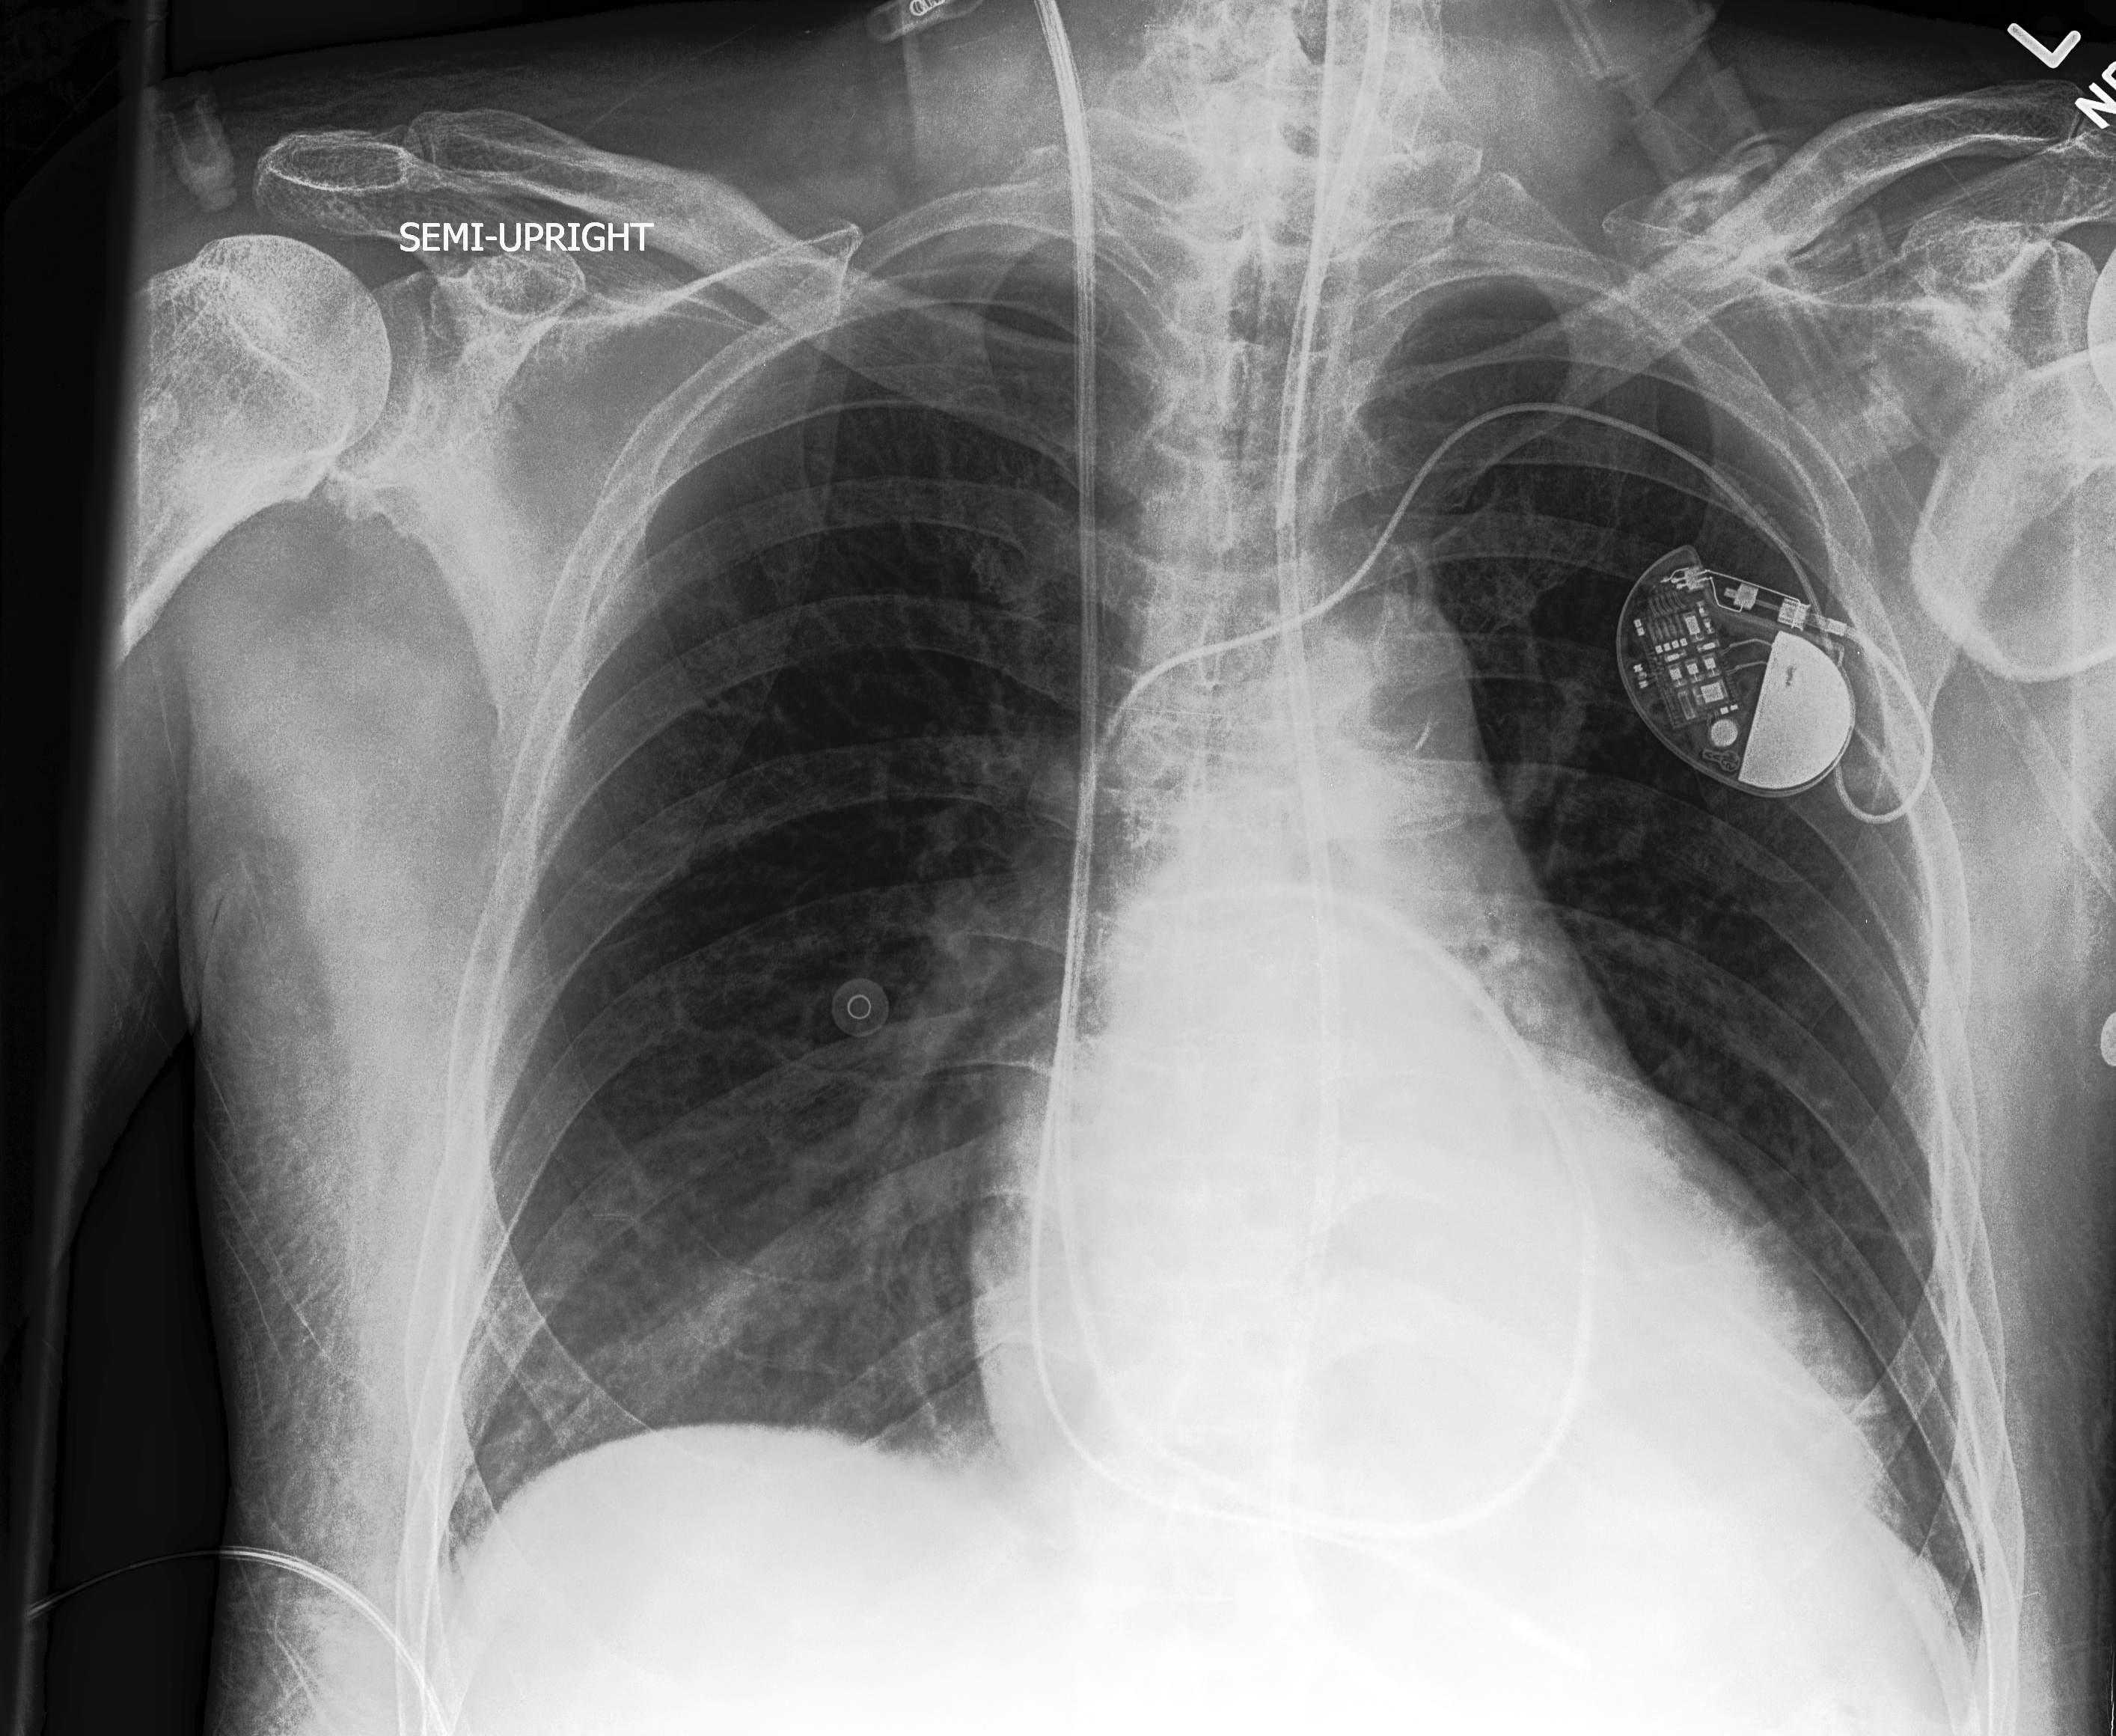

Prepared vision_x shape: [1, 1, 3, 512, 512, 4]
Input metadata saved to: results/input_metadata.json


In [2]:
from PIL import Image

if not IMAGE_PATH.is_file():
    raise FileNotFoundError(f"找不到输入图像：{IMAGE_PATH}。请确认 Quick_demo 样例已准备，或修改 IMAGE_PATH。")

source_image = Image.open(IMAGE_PATH).convert("RGB")
print("Input path:", public_path(IMAGE_PATH))
print("Input size (width, height):", source_image.size)
print("Input mode:", source_image.mode)
print("Input pixel extrema:", source_image.getextrema())
try:
    display(source_image)
except NameError:
    print("Preview display is available when this cell is opened in Jupyter.")

from torchvision import transforms

torch.manual_seed(SEED)
random.seed(SEED)
preprocess = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
])
image_tensor = preprocess(source_image).unsqueeze(0).unsqueeze(-1)
image_tensor = torch.nn.functional.interpolate(image_tensor, size=(IMAGE_SIZE[0], IMAGE_SIZE[1], IMAGE_DEPTH))
VISION_X = torch.cat([image_tensor], dim=1).unsqueeze(0)
VISION_X_SHAPE = list(VISION_X.shape)
print("Prepared vision_x shape:", VISION_X_SHAPE)

input_metadata = {
    "path": public_path(IMAGE_PATH),
    "size": list(source_image.size),
    "mode": source_image.mode,
    "vision_x_shape": VISION_X_SHAPE,
    "preprocessing": "RGB -> RandomResizedCrop(512,512; scale 0.8-1.0) -> ToTensor -> depth 4",
}
(OUTPUT_DIR / "input_metadata.json").write_text(json.dumps(input_metadata, ensure_ascii=False, indent=2), encoding="utf-8")
print("Input metadata saved to:", public_path(OUTPUT_DIR / "input_metadata.json"))

In [3]:
import transformers
from transformers.models.llama import LlamaConfig, LlamaForCausalLM
from transformers import LlamaTokenizer

if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))
from Model.RadFM.multimodality_model import MultiLLaMAForCausalLM

# Language_files contains the LLaMA config/tokenizer; RadFM checkpoint contains its weights.
_original_llama_from_pretrained = LlamaForCausalLM.from_pretrained
def _radfm_llama_from_pretrained(cls, pretrained_model_name_or_path, *args, **kwargs):
    model_dir = Path(pretrained_model_name_or_path)
    weight_names = ("pytorch_model.bin", "model.safetensors", "pytorch_model.bin.index.json", "model.safetensors.index.json")
    if model_dir.is_dir() and not any((model_dir / name).is_file() for name in weight_names):
        return cls(LlamaConfig.from_pretrained(str(model_dir), local_files_only=True))
    return _original_llama_from_pretrained(pretrained_model_name_or_path, *args, **kwargs)
LlamaForCausalLM.from_pretrained = classmethod(_radfm_llama_from_pretrained)
_tokenizer_from_pretrained = transformers.AutoTokenizer.from_pretrained
_model_from_pretrained = transformers.AutoModel.from_pretrained
def _local_tokenizer(identifier, *args, **kwargs):
    return _tokenizer_from_pretrained(str(MED_KEBERT_PATH) if identifier == "xmcmic/Med-KEBERT" else identifier, *args, **kwargs)
def _local_model(identifier, *args, **kwargs):
    return _model_from_pretrained(str(MED_KEBERT_PATH) if identifier == "xmcmic/Med-KEBERT" else identifier, *args, **kwargs)
transformers.AutoTokenizer.from_pretrained = _local_tokenizer
transformers.AutoModel.from_pretrained = _local_model

TOKENIZER = LlamaTokenizer.from_pretrained(str(LANGUAGE_MODEL_PATH), local_files_only=True, bos_token="<s>", eos_token="</s>", unk_token="<unk>", legacy=True)
special_tokens = ["<image>", "</image>"]
IMAGE_PADDING_TOKENS = []
for image_index in range(100):
    tokens = [f"<image{image_index * 32 + patch_index}>" for patch_index in range(32)]
    special_tokens.extend(tokens)
    IMAGE_PADDING_TOKENS.append("".join(tokens))
TOKENIZER.add_special_tokens({"additional_special_tokens": special_tokens})
TOKENIZER.pad_token_id, TOKENIZER.bos_token_id, TOKENIZER.eos_token_id = 0, 1, 2

MODEL = MultiLLaMAForCausalLM(lang_model_path=str(LANGUAGE_MODEL_PATH))
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
state_dict = checkpoint.get("state_dict", checkpoint) if isinstance(checkpoint, dict) else checkpoint
missing, unexpected = MODEL.load_state_dict(state_dict, strict=False)
MODEL = MODEL.to(DEVICE).eval()
RUNTIME_INFO = {
    "status": "generated",
    "device": DEVICE,
    "torch": torch.__version__,
    "gpu": torch.cuda.get_device_name(0),
    "missing_keys": len(missing),
    "unexpected_keys": len(unexpected),
    "model_device": str(next(MODEL.parameters()).device),
}
print("Loaded RadFM on:", RUNTIME_INFO["model_device"])
print("沐曦 GPU:", RUNTIME_INFO["gpu"])

(OUTPUT_DIR / "runtime.json").write_text(json.dumps(RUNTIME_INFO, ensure_ascii=False, indent=2), encoding="utf-8")
print("Runtime metadata saved to:", public_path(OUTPUT_DIR / "runtime.json"))

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/opt/conda/lib/python3.12/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/opt/conda/lib/python3.12/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https:/

/opt/conda/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:568: UserWarning: `pad_token_id` should be positive but got -1. This will cause errors when batch generating, if there is padding. Please set `pad_token_id` explicitly as `model.generation_config.pad_token_id=PAD_TOKEN_ID` to avoid errors in generation
  warnings.warn(


Loaded RadFM on: cuda:0
沐曦 GPU: MetaX C500
Runtime metadata saved to: results/runtime.json


In [4]:
def build_prompt(question):
    return "<image>" + IMAGE_PADDING_TOKENS[0] + "</image>" + question


def save_task_result(task_name, result):
    result_path = OUTPUT_DIR / f"{task_name}.json"
    result_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
    print(json.dumps(result, ensure_ascii=False, indent=2))
    print("Saved result:", public_path(result_path))
    return result


def run_task(task_name, question):
    prompt = build_prompt(question)
    lang_x = TOKENIZER(prompt, max_length=MAX_LENGTH, truncation=True, return_tensors="pt")["input_ids"].to(DEVICE)
    vision_x = VISION_X.to(DEVICE)
    with torch.inference_mode():
        generation = MODEL.generate(lang_x, vision_x)
    answer = TOKENIZER.batch_decode(generation, skip_special_tokens=True)[0].strip()
    return save_task_result(task_name, {
        "task": task_name,
        "question": question,
        "answer": answer,
        "status": "generated",
        "input": public_path(IMAGE_PATH),
        "vision_x_shape": list(vision_x.shape),
        "device": str(vision_x.device),
    })

## 2. 沐曦GPU 运行效果展示

参数单元准备输入，模型单元加载 RadFM；以下三个代码单元分别执行一次官方 `generate`，打印模型回答和设备，并保存到独立 JSON 文件。

| 任务单元 | 提示词 | 输出文件 |
| --- | --- | --- |
| `vqa_cardiomegaly` | 官方 Quick_demo 的 Cardiomegaly 是/否问题 | `vqa_cardiomegaly.json` |
| `report_generation` | 简洁胸片放射学报告 | `report_generation.json` |
| `rationale` | 描述支持回答的可见征象 | `rationale.json` |

任务单元只展示本次生成的文本和结果文件路径，不记录耗时。

### 2.1 Cardiomegaly 视觉问答

本单元对应官方 Quick_demo 的单轮问题；回答来自本次 `generate`，不是预先写入的示例文本。

In [5]:
vqa_result = run_task("vqa_cardiomegaly", TASKS["vqa_cardiomegaly"])

/opt/conda/lib/python3.12/site-packages/torch/nn/functional.py:6006: UserWarning: 1Torch was not compiled with memory efficient attention. (Triggered internally at /workspace/framework/mcPytorch/aten/src/ATen/native/transformers/cuda/sdp_utils.cpp:772.)
  return _scaled_dot_product_attention(query, key, value, attn_mask, dropout_p, is_causal, scale = scale, enable_gqa = enable_gqa)


{
  "task": "vqa_cardiomegaly",
  "question": "Can you identify any visible signs of Cardiomegaly in the image?",
  "answer": "yes",
  "status": "generated",
  "input": "/workspace/radfm-assets/RadFM/Quick_demo/view1_frontal.jpg",
  "vision_x_shape": [
    1,
    1,
    3,
    512,
    512,
    4
  ],
  "device": "cuda:0"
}
Saved result: results/vqa_cardiomegaly.json


### 2.2 胸片放射学报告生成

本单元只执行报告提示词的一次生成，并将原始文本保存为独立结果文件。

In [6]:
report_result = run_task("report_generation", TASKS["report_generation"])

{
  "task": "report_generation",
  "question": "Please provide a concise radiology report for this chest X-ray.",
  "answer": "Lung Opacity Effusion Support Devices",
  "status": "generated",
  "input": "/workspace/radfm-assets/RadFM/Quick_demo/view1_frontal.jpg",
  "vision_x_shape": [
    1,
    1,
    3,
    512,
    512,
    4
  ],
  "device": "cuda:0"
}
Saved result: results/report_generation.json


### 2.3 可见征象解释

本单元以独立提示词请求可见征象描述；该文本仍是生成模型输出，不是临床结论。

In [7]:
rationale_result = run_task("rationale", TASKS["rationale"])

{
  "task": "rationale",
  "question": "Describe the visible findings that support your answer about this chest X-ray. Do not provide medical advice.",
  "answer": "This is an Aunt Minnie.",
  "status": "generated",
  "input": "/workspace/radfm-assets/RadFM/Quick_demo/view1_frontal.jpg",
  "vision_x_shape": [
    1,
    1,
    3,
    512,
    512,
    4
  ],
  "device": "cuda:0"
}
Saved result: results/rationale.json


---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。

Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.